Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
x_train shape after processing: (60000, 28, 28, 1)
y_train shape after processing: (60000, 10)


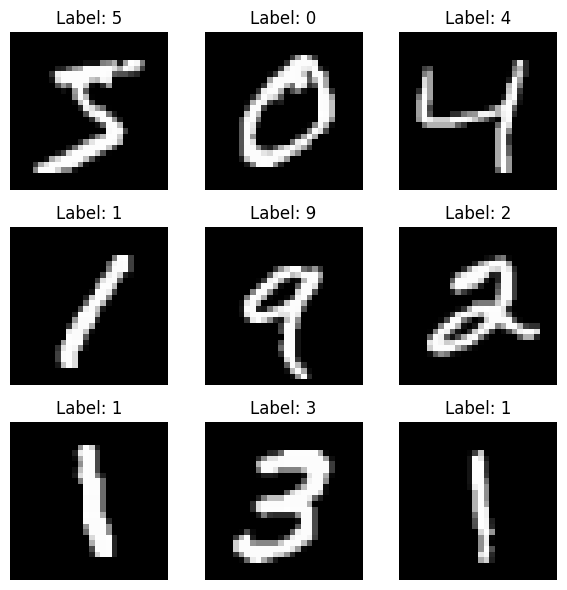

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Starting Model Training...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.9418 - loss: 0.1926 - val_accuracy: 0.9877 - val_loss: 0.0459
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.9818 - loss: 0.0614 - val_accuracy: 0.9888 - val_loss: 0.0386
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 58ms/step - accuracy: 0.9874 - loss: 0.0421 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 56ms/step - accuracy: 0.9903 - loss: 0.0315 - val_accuracy: 0.9903 - val_loss: 0.0360
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9920 - loss: 0.0259 - val_accuracy: 0.9925 - val_loss: 0.0280

Test Loss: 0.0247
Test Accuracy: 99.19%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


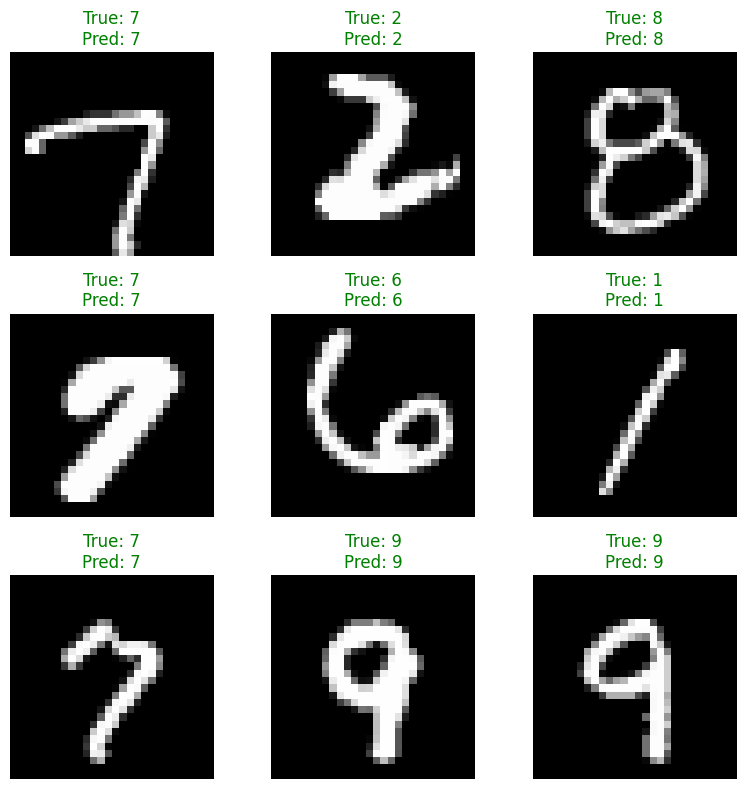


--- Predict New Data ---
Please click 'Choose Files' below to upload an image of a digit (PNG/JPG):


Saving no7.webp to no7.webp
Successfully loaded: no7.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


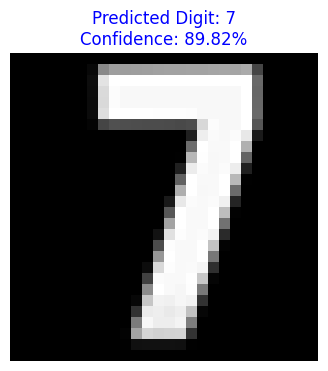

In [3]:
# ==============================================================================
# CELL 1: Import essential libraries
# ==============================================================================
import os
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

# ==============================================================================
# CELL 2: Load the MNIST dataset
# ==============================================================================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# ==============================================================================
# CELL 4: Reshape the data for CNN (Adding channel dimension)
# ==============================================================================
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# ==============================================================================
# CELL 6: Normalize pixel values
# ==============================================================================
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# ==============================================================================
# CELL 8: One-hot encode the labels
# ==============================================================================
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("x_train shape after processing:", x_train.shape)
print("y_train shape after processing:", y_train.shape)

# ==============================================================================
# CELL 10: Visualize the first 9 training digits
# ==============================================================================
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# ==============================================================================
# CELL 12: Build the CNN Model Architecture
# ==============================================================================
model = Sequential()

# First Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

# Second Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten the 2D feature maps to a 1D vector
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

# Summary of the model structure
model.summary()

# ==============================================================================
# CELL 14: Compile and Train the Model
# ==============================================================================
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\nStarting Model Training...")
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.1)

# ==============================================================================
# CELL 16: Evaluate the Performance on Test Data
# ==============================================================================
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# ==============================================================================
# CELL 18: Image Identification Prediction Output on Test Set
# ==============================================================================
predictions = model.predict(x_test)

plt.figure(figsize=(8, 8))
random_indices = np.random.choice(len(x_test), 9, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')

    true_label = np.argmax(y_test[idx])
    predicted_label = np.argmax(predictions[idx])
    title_color = 'green' if true_label == predicted_label else 'red'

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# ==============================================================================
# CELL 19: Predict Custom New Data (Browser Upload Compatibility)
# ==============================================================================
print("\n--- Predict New Data ---")

img = None

# 1. Attempt Google Colab upload method
try:
    from google.colab import files
    print("Please click 'Choose Files' below to upload an image of a digit (PNG/JPG):")
    uploaded = files.upload()
    if uploaded:
        file_name = list(uploaded.keys())[0]
        img = Image.open(io.BytesIO(uploaded[file_name])).convert('L')
        print(f"Successfully loaded: {file_name}")

# 2. Fallback to standard Jupyter Notebook upload widget if Colab isn't active
except ImportError:
    try:
        import ipywidgets as widgets
        from IPython.display import display

        print("Please use the button below to upload your image file:")
        uploader = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
        display(uploader)
        print("\n[NOTE]: If uploading via widget, please make sure you uploaded the file before running verification logic.")

        # Extract the content from the uploader object if present
        if uploader.value:
            # Handle differences between ipywidgets v7 and v8 structures
            if isinstance(uploader.value, dict):
                uploaded_file = list(uploader.value.values())[0]
                img_content = uploaded_file['content']
            else:
                uploaded_file = uploader.value[0]
                img_content = uploaded_file['content']

            img = Image.open(io.BytesIO(img_content)).convert('L')
    except Exception as e:
        print("Interactive widgets are unavailable. Checking for manual file pathway...")

# 3. Final Fallback: Manual filename placement check if no browser window triggered
if img is None:
    manual_filename = "digit.png"  # Adjust this string name to match any image you put in your directory
    if os.path.exists(manual_filename):
        img = Image.open(manual_filename).convert('L')
        print(f"Loaded file manually from local workspace: {manual_filename}")
    else:
        print(f"\n[Warning]: No file uploaded. To manually predict, drop an image named '{manual_filename}' in your file list.")

# Process and run prediction on the image if successfully retrieved
if img is not None:
    # Resize image to match model criteria (28x28 pixels)
    img = img.resize((28, 28))
    img_array = image.img_to_array(img)

    # Invert binary space if image background is white with dark text (MNIST is dark background with white text)
    if np.mean(img_array) > 127:
        img_array = 255 - img_array

    # Scale inputs to standard float density normalization range [0, 1]
    img_array = img_array.astype("float32") / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # Generate visual outputs
    custom_prediction = model.predict(img_input)
    predicted_digit = np.argmax(custom_prediction)
    confidence = np.max(custom_prediction) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted Digit: {predicted_digit}\nConfidence: {confidence:.2f}%", fontsize=12, color='blue')
    plt.axis('off')
    plt.show()